# Problem Statement: <br>
Consider the Boston Housing Market Dataset. The link to the dataset has been attached.
You need to report the following:

1. Create the histogram of all the features in the dataset.
2. Find the correlation matrix and plot it in a heatmap.
3. Plot the 'Scatter Plot' for all the features in correspondence to the target feature 'MEDV - Median value of owner-occupied homes in $1000's'.
4. Detect any outliers from the scatter plot.



# Dataset Description: <br>

Dataset contains **506 observations** and 14 **attributes**.

**Context**<br>
The Boston house-price data of Harrison, D. and Rubinfeld, D.L.*'Hedonic prices and the demand for clean air'*, *J. Environ. Economics & Management*,* vol.5, 81-102, 1978*.<br>

**Attribute Information**
Input features in order:
1) CRIM: per capita crime rate by town
2) ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
3) INDUS: proportion of non-retail business acres per town
4) CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
5) NOX: nitric oxides concentration (parts per 10 million) [parts/10M]
6) RM: average number of rooms per dwelling
7) AGE: proportion of owner-occupied units built prior to 1940
8) DIS: weighted distances to five Boston employment centres
9) RAD: index of accessibility to radial highways
10) TAX: full-value property-tax rate per $10,000
11) PTRATIO: pupil-teacher ratio by town
12) B: The result of the equation B=1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
13) LSTAT: % lower status of the population

**Output variable:**
1) MEDV: Median value of owner-occupied homes in $1000's



> Link to dataset: https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data



# Source Code:

## Library Function

In [ ]:
import pandas as pd                           # For dataset handling.
import numpy as np                            # For mathematical operation.
import seaborn as sns                         # For advance statistical library.
import matplotlib.pyplot as plt               # For graph ploting.
from sklearn.impute import SimpleImputer      # For removing missing values from dataset.
from scipy import stats                       # For probability distribution.
import warnings                               # For ignoring warning.

## Load Dataset

In [ ]:
warnings.filterwarnings('ignore')                      #Ignore warning messages
"""
Load and preprocess a dataset from a file path
Supports CSV, Excel, and JSON formats
"""
file_path = input("Enter the filepath: ")
# Determine file type and load data
if file_path.endswith('.csv'):
    df = pd.read_csv(file_path)
elif file_path.endswith(('.xlsx', '.xls')):
    df = pd.read_excel(file_path)
elif file_path.endswith('.json'):
    df = pd.read_json(file_path)
else:
    raise ValueError("Unsupported file format. Please use CSV, Excel, or JSON.")

print(f"Original dataset shape: {df.shape}")

Enter the filepath: /content/boston.csv
Original dataset shape: (506, 14)


## Data Pre-processing

1. Handle missing value per column.
2. Remove duplicate rows.



In [7]:
"""
Perform data cleaning operations
"""
# Create a copy of the dataframe
df_clean = df.copy()

# 1. Handle missing values
print("\n1. Handling missing values...")
missing_values = df_clean.isnull().sum()
print(f"Missing values per column:\n{missing_values[missing_values > 0]}")
if df_clean.isnull().values.sum() > 0:
    median_val = df_clean.median(numeric_only=True)
    df_clean.fillna(median_val, inplace=True)
    print(f"Filled missing values with column-wise medians:\n{median_val}")

# 2. Remove duplicates
print("\n2. Removing duplicates...")
initial_count = len(df_clean)
df_clean.drop_duplicates(inplace=True)
final_count = len(df_clean)
print(f"Removed {initial_count - final_count} duplicate rows")

print(f"\nCleaned dataset shape: {df_clean.shape}")


1. Handling missing values...
Missing values per column:
Series([], dtype: int64)

2. Removing duplicates...
Removed 0 duplicate rows

Cleaned dataset shape: (506, 14)


##Ploting Histogram along with distribution line.

Enter output file name for histogram(default histograms.pdf): 

Histograms saved as 'histograms.pdf'


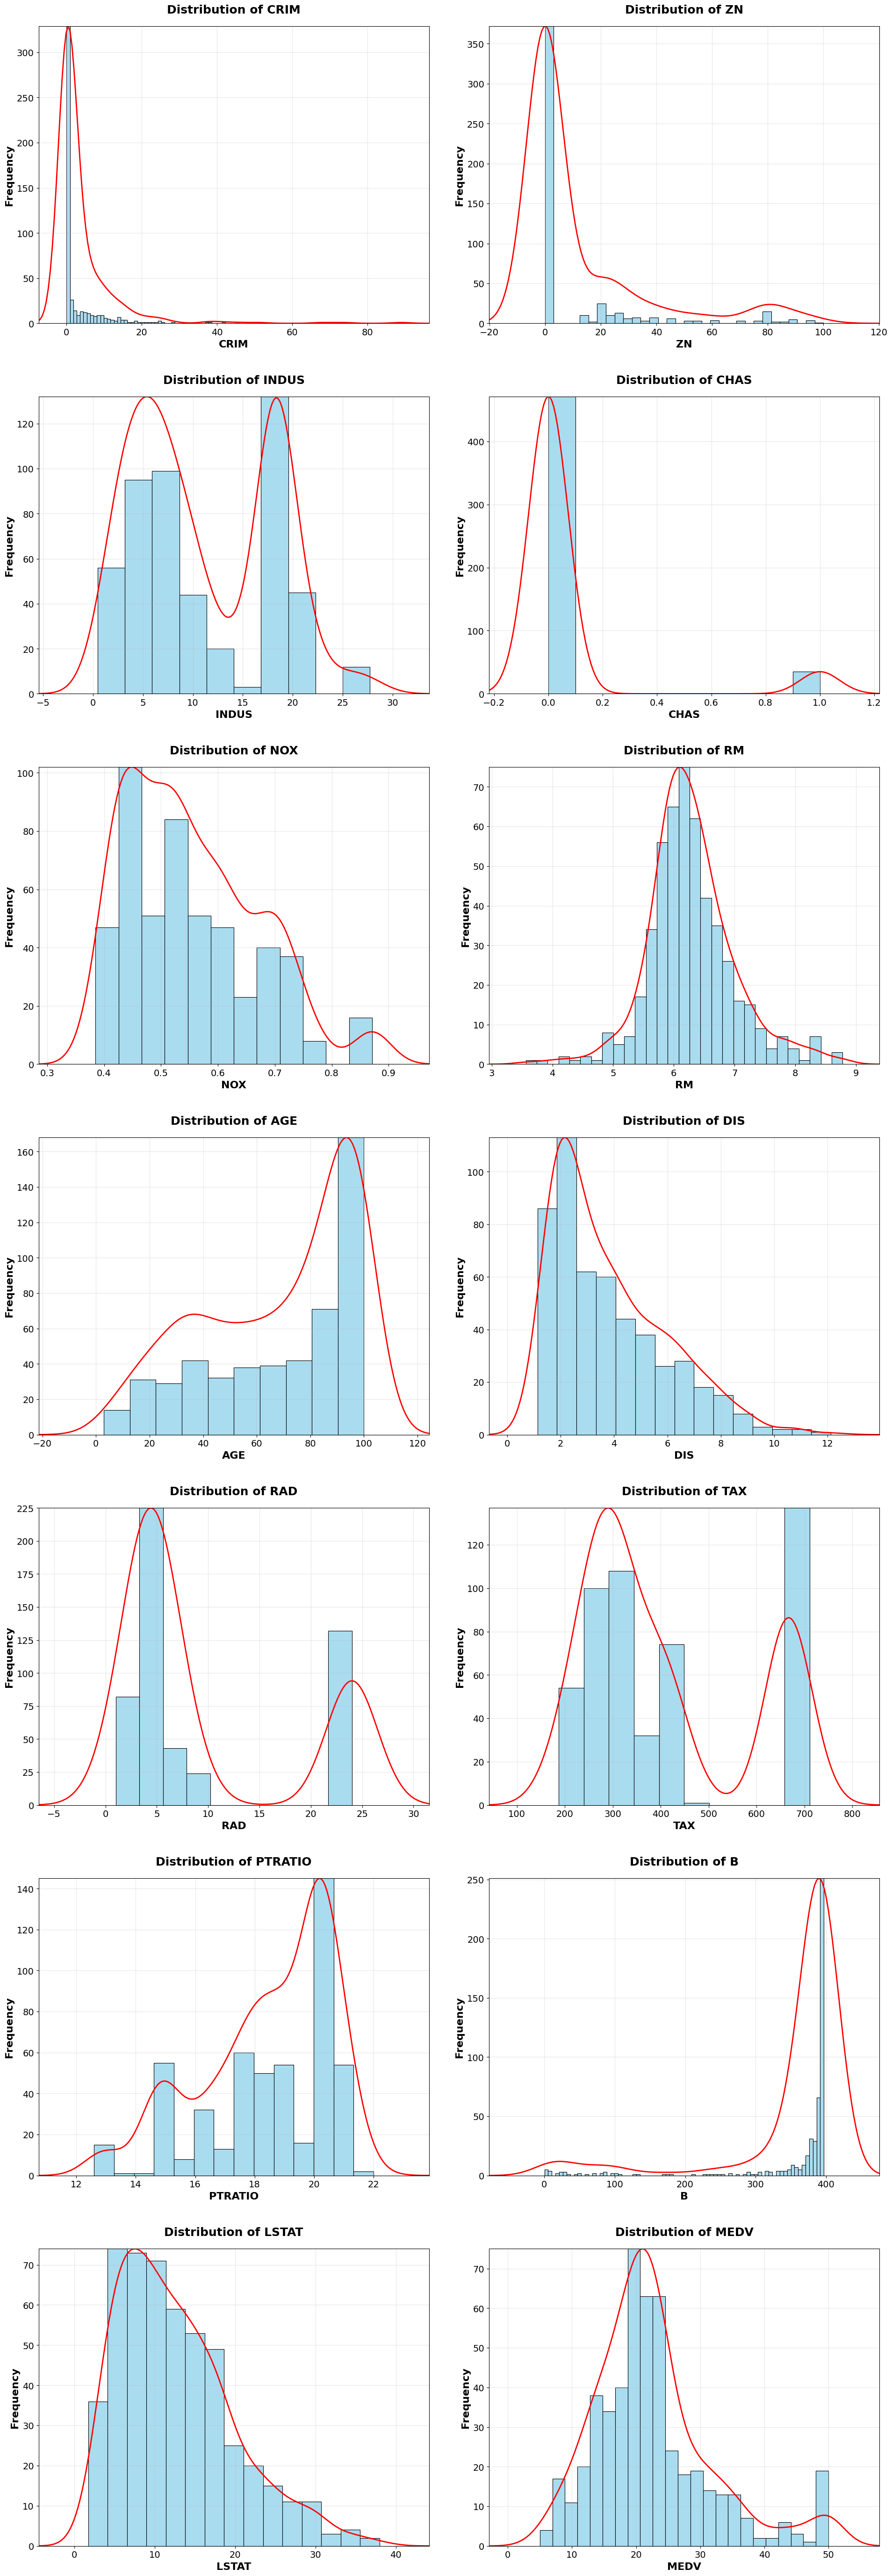

In [8]:
"""
Plot frequency histograms for all numeric columns
arranged in a grid with 2 columns, and save as PDF
"""

kde_color = 'red'                                              # Set the distribution line color
save_path = 'histograms.pdf'
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns


# Set up the subplot grid
n_cols = 2
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

# Create figure and axes with appropriate size
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8*n_rows))

# If only one row, axes might not be 2D
if n_rows == 1:
    axes = axes.reshape(1, -1)

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Plot frequency histogram for each numeric column
for i, column in enumerate(numeric_cols):
    # Plot histogram with frequency (count)
    ax = sns.histplot(df[column], kde=False, stat='count', alpha=0.7,
                      edgecolor='black', linewidth=0.8, ax=axes_flat[i],
                      color='skyblue')

    # Add KDE with custom color and scale it to match frequency
    kde = sns.kdeplot(df[column], color=kde_color, linewidth=2, ax=ax)

    # Get the KDE line data
    line = ax.lines[0]
    x_data = line.get_xdata()
    y_data = line.get_ydata()

    # Scale the KDE to match the histogram
    hist_data = ax.containers[0].datavalues
    max_hist = max(hist_data) if len(hist_data) > 0 else 1
    max_kde = max(y_data) if len(y_data) > 0 else 1
    scaling_factor = max_hist / max_kde

    # Remove the original KDE line
    ax.lines[0].remove()

    # Plot the scaled KDE
    ax.plot(x_data, y_data * scaling_factor, color=kde_color, linewidth=2)

    # Customize the plot
    axes_flat[i].set_title(f'Distribution of {column}', fontsize=18, fontweight='bold', pad=20)
    axes_flat[i].set_xlabel(column, fontsize=16, fontweight='bold')
    axes_flat[i].set_ylabel('Frequency', fontsize=16, fontweight='bold')
    axes_flat[i].tick_params(axis='both', which='major', labelsize=14)
    axes_flat[i].grid(True, alpha=0.3)
    axes_flat[i].ticklabel_format(style='plain', axis='x')
    axes_flat[i].autoscale(enable=True, axis='both', tight=True)

# Hide any unused subplots
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

# Adjust layout with more padding
plt.tight_layout(pad=4.0)

# Save the figure as PDF
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\nHistograms saved as '{save_path}'")
plt.show()
plt.close()


### Conclusion on Histograms:
We can observe that features such as CRIM, AGE, DIS, B, and LSTAT are skewed; therefore, we can apply log or square root transformations. <br>
The feature ZN has a high concentration of zeros. <br>
Features such as RM, NOX, and MEDV are approximately normally distributed, with slight skewness.

## Correlation matrix using heatmap

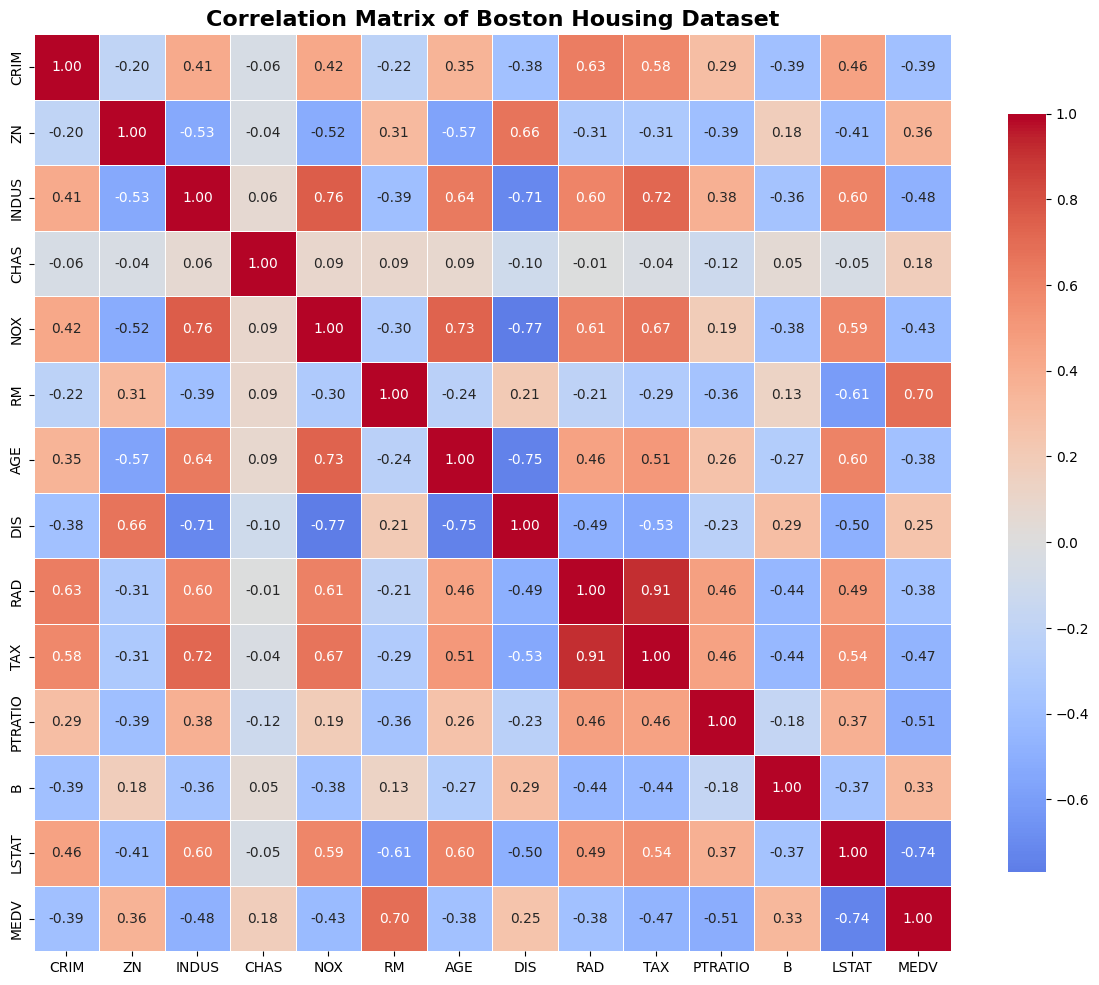

In [9]:
# Calculate correlation matrix
correlation_matrix = df_clean.corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix of Boston Housing Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


### Conclusion on Correlation Matrix:


1. Strong Positive Correlations (≥ 0.7):
    * TAX and RAD (0.91): Very strong positive correlation properties with higher accessibility to highways tend to have higher tax rates.

    * NOX and INDUS (0.76): Strong positive correlation areas with more industry tend to have higher nitric oxide concentrations
    
    * RM and MEDV(0.70): Number of rooms has the strongest positive relationship with home value


2. Strong Negative Correlations (≤ -0.7):
    * DIS and NOX (-0.77): Strong negative correlation as distance from employment centers increases, pollution decreases

    * DIS and INDUS (-0.71): Strong negative correlation properties farther from employment centers tend to have less industry
    * LSTAT and MEDV(-0.74): Percentage of lower status population strongly negatively correlates with home value

<br>
TAX and RAD are highly correlated (0.91), which may cause multicollinearity issues.


## Outlier Detection using Scatterplot - Target Variable[MEDV]


Scatter plots saved as 'scatterplots_MEDV_IQR.pdf'


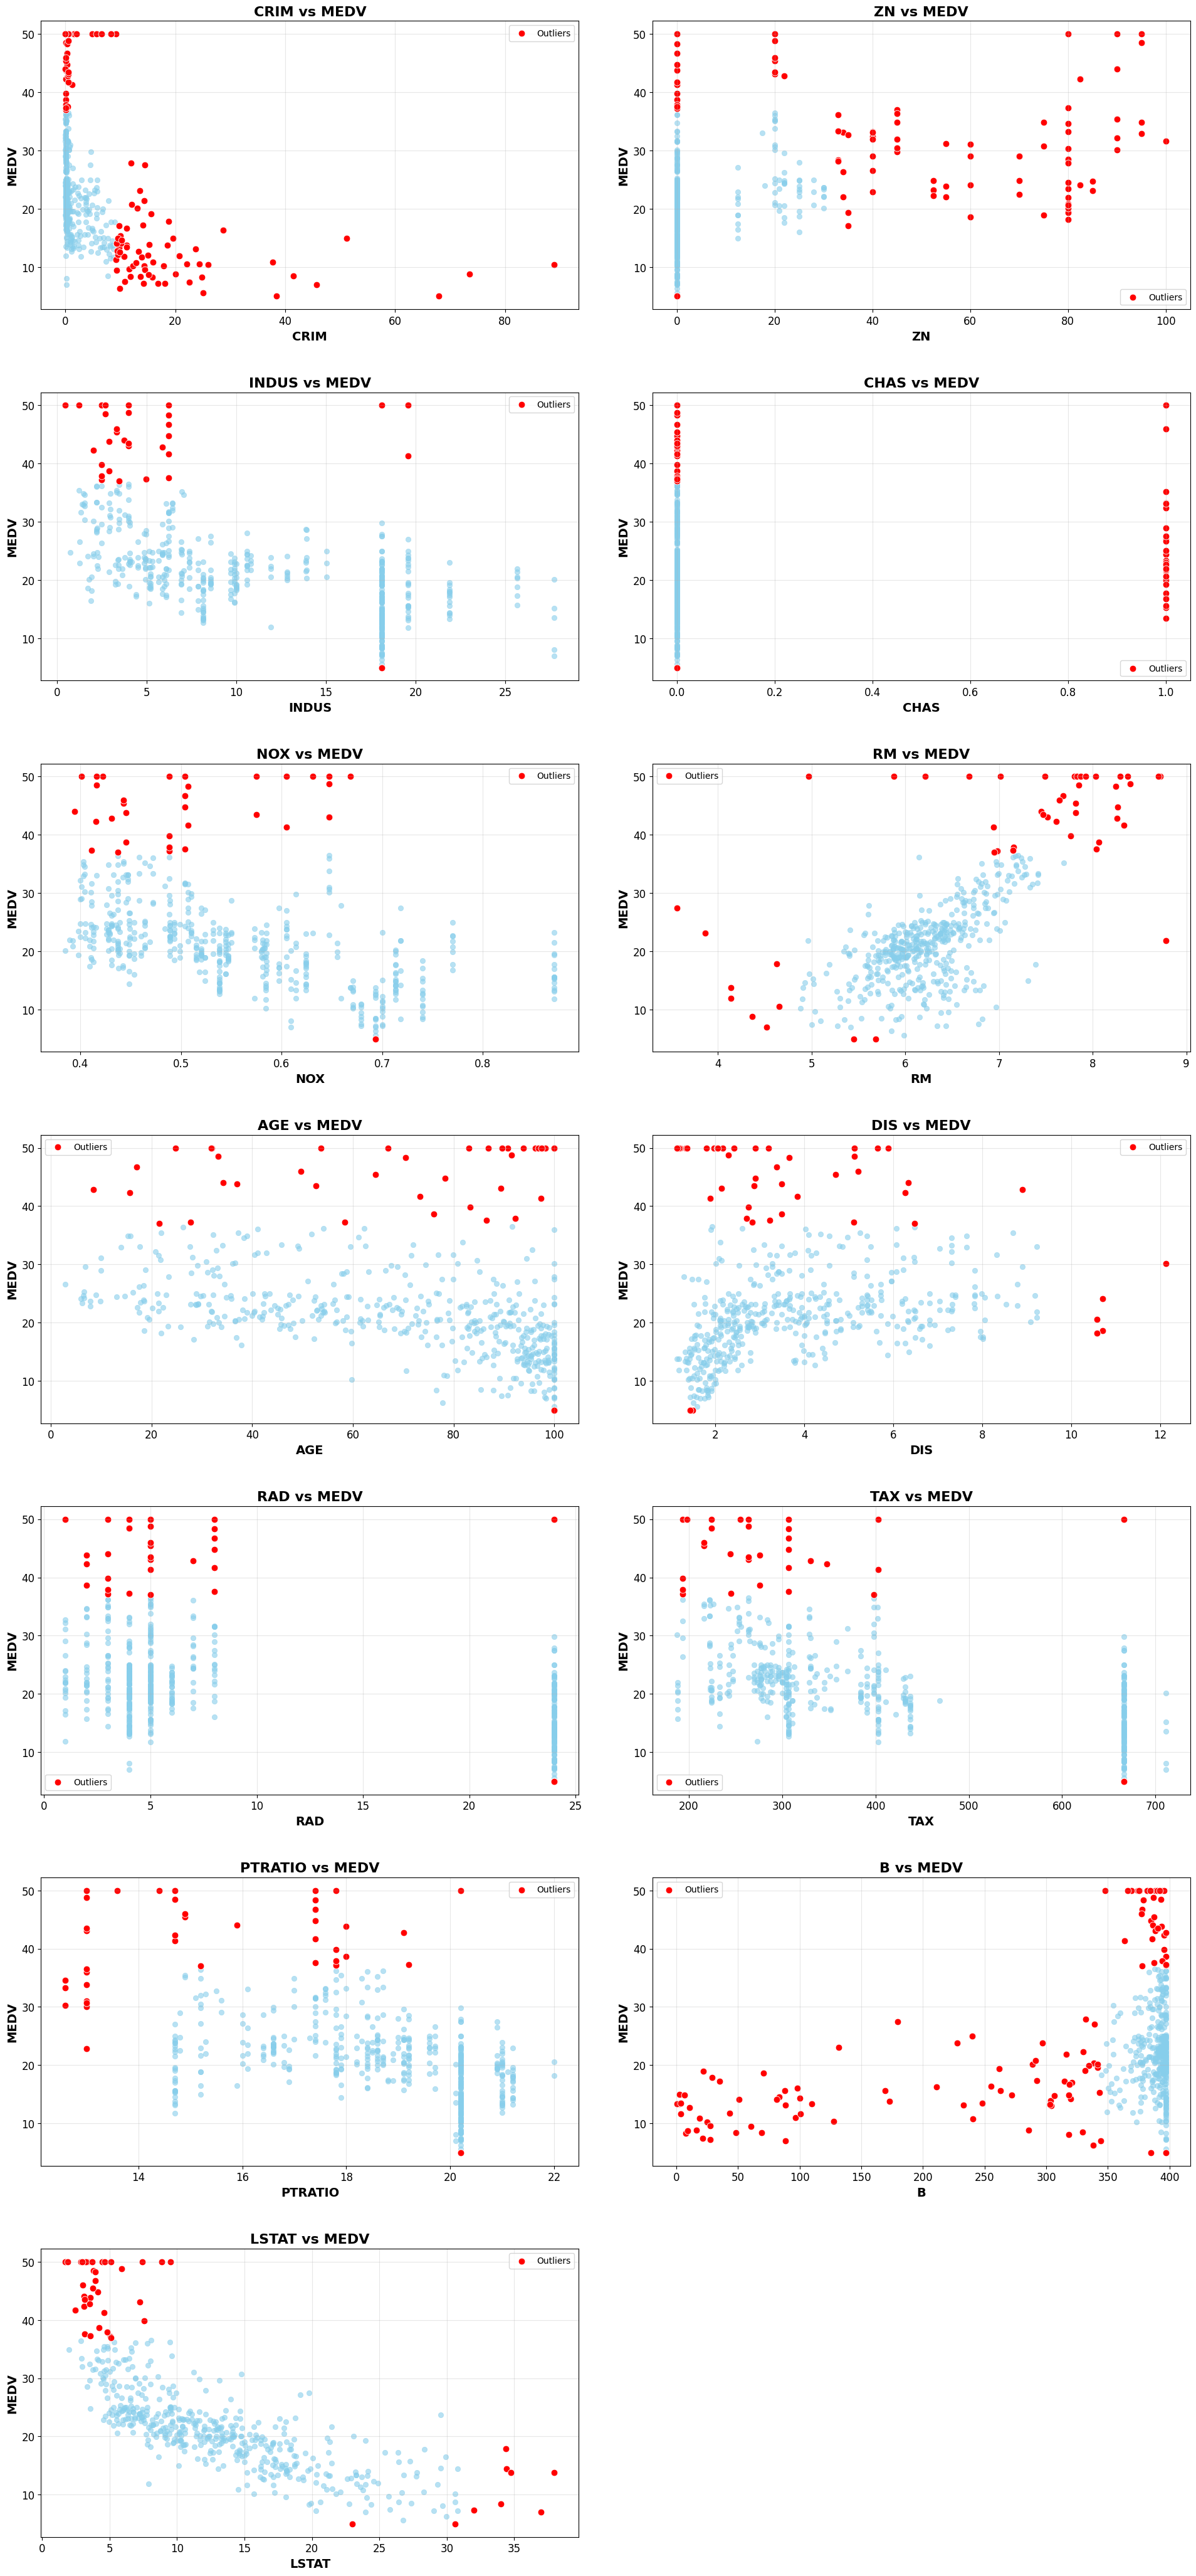

In [15]:
# Target variable
target = 'MEDV'

# Select numeric columns excluding MEDV
features = [col for col in df_clean.select_dtypes(include=[np.number]).columns if col != target]

# Subplot grid (2 columns)
n_cols = 2
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
axes = axes.flatten()

def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col] < lower) | (data[col] > upper)]

for i, feature in enumerate(features):
    ax = axes[i]

    # Scatter plot
    sns.scatterplot(data=df_clean, x=feature, y=target,
                    alpha=0.6, edgecolor=None, color='skyblue', ax=ax)

    # Detect outliers using IQR (on feature and target separately, then combine)
    outliers_feat = detect_outliers_iqr(df_clean, feature)
    outliers_target = detect_outliers_iqr(df_clean, target)
    outliers = pd.concat([outliers_feat, outliers_target]).drop_duplicates()

    # Overlay outliers
    sns.scatterplot(data=outliers, x=feature, y=target,
                    color='red', marker='o', s=60, ax=ax, label='Outliers')

    ax.set_title(f'{feature} vs {target}', fontsize=16, fontweight='bold')
    ax.set_xlabel(feature, fontsize=14, fontweight='bold')
    ax.set_ylabel(target, fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(pad=4.0)
plt.savefig('scatterplots_MEDV_IQR.pdf', bbox_inches='tight')  # Save in pdf format
print("\nScatter plots saved as 'scatterplots_MEDV_IQR.pdf'")
plt.show()
plt.close()